<a href="https://colab.research.google.com/github/EdmundoMarquez/AnalisisDatos_IA/blob/main/Hands_On_Exploraci%C3%B3n_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HANDS - ON: EXPLORACIÓN DE DATOS**



Una vez visto la presentación ***Exploración de datos***, se proporciona el siguiente ***colab*** para que **el alumnado pueda practicar** haciendo uso del lenguaje de programación ***python***.

Para este notebook, se hará uso del siguiente dataset: [enlace](https://drive.google.com/file/d/1hX8uxJp5h03eYrgAnyznp8yeeG2syiD_/view?usp=drive_link)

De igual manera, se proporciona la **solución** de este notebook a través del siguiente [enlace](https://colab.research.google.com/drive/1eXIB1nd8aaBZWDYBXlIlfCOVkAe-ETrI?usp=drive_link).

## **ANÁLISIS EXPLORATORIO**

El **Análisis Exploratorio de Datos (EDA)** es la etapa donde **se descubren patrones, se detectan anomalías y se comprueban hipótesis mediante estadísticas y visualizaciones**. Es el proceso fundamental para entender la salud de la información antes de cualquier toma de decisiones.

A través de herramientas descriptivas y gráficos de dispersión, esta fase permite limpiar inconsistencias y validar la calidad de la muestra. Su ejecución garantiza que las conclusiones posteriores se apoyen en evidencia real, minimizando sesgos y optimizando la precisión de los modelos predictivos.

In [118]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Inicializar drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [119]:
# Importar datos
ruta_colab = '/content/drive/MyDrive/AnalisisDatos/Assets/youtube_clean.csv'
df_yt = pd.read_csv(ruta_colab)

df_yt

,video_id,título,categoría,views,likes,dislikes,comentarios,duración_min,fecha_publicación
0,1,título,música,129257,11299,21,8790,127,2024-07-02
1,2,título,películas,247904,15579,211,4775,63,2022-02-13
2,3,sin título,comedia,3073,14780,1095,9847,55,2016-07-06
3,4,título,gaming,268858,2691,4420,7614,78,2017-12-03
4,5,título,gaming,162893,16521,2294,6508,143,2023-11-24
...,...,...,...,...,...,...,...,...,...
303,106,título,películas,150272,11299,4605,6716,213,2021-09-04
304,131,título,tecnología,25407,9999999,2437,4498,137,2025-07-18
305,6,título,películas,42160,10721,3547,9033,58,2025-08-27
306,97,título,deportes,13530,14437,2631,2629,158,2018-03-12


In [120]:
# Ver resumen estadístico de las columnas numéricas

columnas_numericas = ['views', 'likes', 'dislikes', 'comentarios', 'duración_min']
df_yt[columnas_numericas].describe()

,views,likes,dislikes,comentarios,duración_min
count,308.000000,3.080000e+02,308.000000,308.000000,308.000000
mean,144805.269481,6.265995e+05,12193.288961,5058.188312,139.853896
std,86246.543475,2.407311e+06,52900.153300,2940.396104,139.066834
min,1691.000000,9.700000e+01,21.000000,12.000000,1.000000
25%,74129.500000,5.774250e+03,1523.750000,2667.500000,58.000000
50%,129257.000000,1.129900e+04,2590.000000,4931.500000,123.500000
75%,224050.750000,1.575300e+04,3777.500000,7740.750000,181.500000
max,299408.000000,9.999999e+06,300408.000000,9987.000000,800.000000


### **VALORES ATÍPICOS Y TRATAMIENTO**

**Los valores atípicos son observaciones que se alejan significativamente del resto de los datos**. Pueden ser causados por errores en la entrada de datos o por fenómenos naturales del dataset.

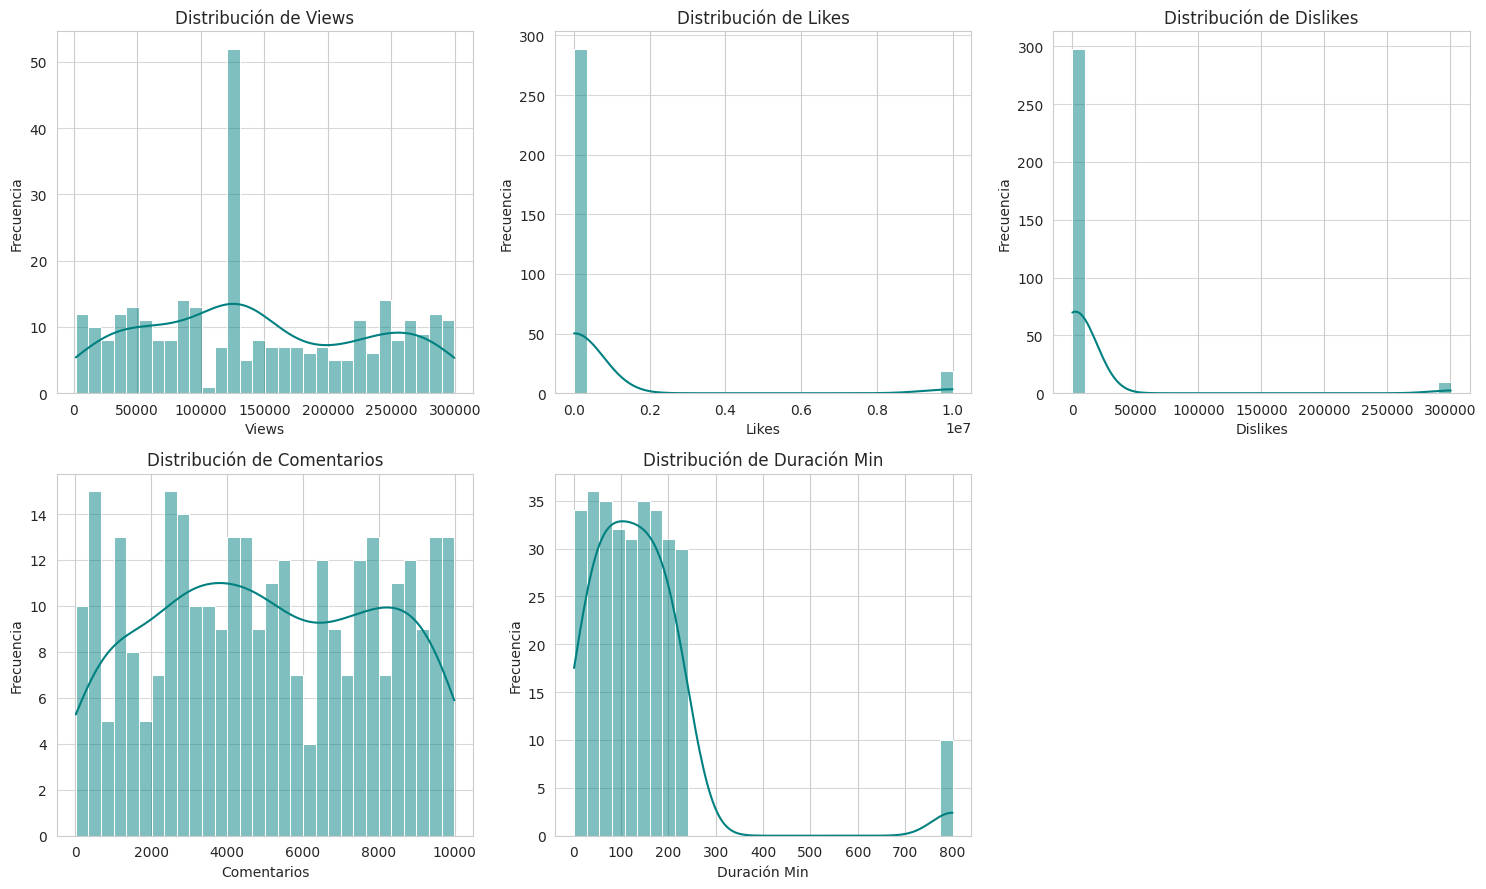

In [121]:
# Observar distribución de los datos

plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_yt[col], bins=30, kde=True, color='teal')
    plt.title(f'Distribución de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

# Todas las distribuciones no son normales y casi todos tienen valores extremos.

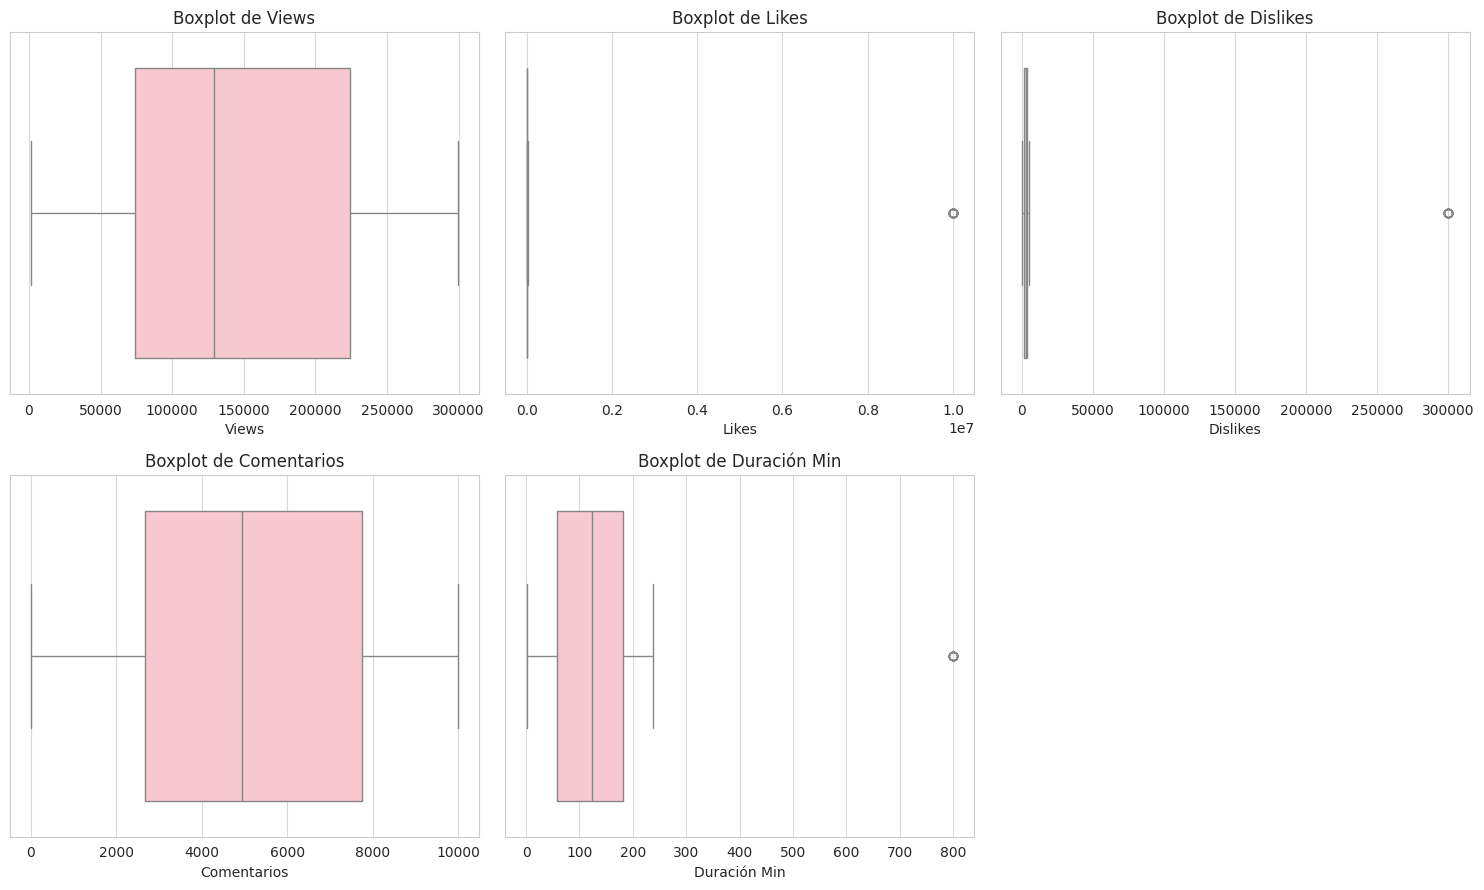

In [122]:
# Observar comportamiento cuartil de los datos

plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df_yt[col], color='pink')
    plt.title(f'Boxplot de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.grid(axis='x', alpha=0.75)

plt.tight_layout()
plt.show()

# Tres gráficos de caja presentan valores extremos

In [123]:
df_yt[columnas_numericas].describe()

,views,likes,dislikes,comentarios,duración_min
count,308.000000,3.080000e+02,308.000000,308.000000,308.000000
mean,144805.269481,6.265995e+05,12193.288961,5058.188312,139.853896
std,86246.543475,2.407311e+06,52900.153300,2940.396104,139.066834
min,1691.000000,9.700000e+01,21.000000,12.000000,1.000000
25%,74129.500000,5.774250e+03,1523.750000,2667.500000,58.000000
50%,129257.000000,1.129900e+04,2590.000000,4931.500000,123.500000
75%,224050.750000,1.575300e+04,3777.500000,7740.750000,181.500000
max,299408.000000,9.999999e+06,300408.000000,9987.000000,800.000000


#### **RANGO INTERCUARTILICO**

El **Rango Intercuartílico (IQR)** es una medida fundamental de dispersión estadística, utilizada principalmente para detectar y manejar **valores atípicos (outliers)** en un conjunto de datos. Se calcula como la diferencia entre el tercer cuartil (Q3) y el primer cuartil (Q1):

$$IQR = Q3 - Q1$$

Para identificar outliers, se definen límites:

*   **Límite Inferior (LI):** $LI = Q1 - 1.5 \times IQR$

*   **Límite Superior (LS):** $LS = Q3 + 1.5 \times IQR$


In [124]:
# Ver cantidad de registros iniciales

print(f'Cantidad de datos iniciales: {len(df_yt)}')

Cantidad de datos iniciales: 308


In [125]:
columnas_numericas

['views', 'likes', 'dislikes', 'comentarios', 'duración_min']

In [126]:
# Calculo del IQR

df_copy = df_yt.copy() # Preservar el dataset haciendo una copia

for col in columnas_numericas:

  Q1 = df_copy[col].quantile(0.25) # Primer cuartil
  Q3 = df_copy[col].quantile(0.75) # Tercer cuartil
  IQR = Q3 - Q1 # Rango intercuartilico

  lim_inf_iqr = Q1 - 1.5 * IQR # Limite inferior
  lim_sup_iqr = Q3 + 1.5 * IQR # Limite superior

  cant_inicial = len(df_copy)
  # Filtro de los datos dentro de los limites
  df_copy = df_copy[(df_copy[col] >= lim_inf_iqr) & (df_copy[col] <= lim_sup_iqr)]
  cant_final = len(df_copy)

  print(f"Columna '{col}': Se eliminaron {cant_inicial - cant_final} registros.")


Columna 'views': Se eliminaron 0 registros.
Columna 'likes': Se eliminaron 19 registros.
Columna 'dislikes': Se eliminaron 10 registros.
Columna 'comentarios': Se eliminaron 0 registros.
Columna 'duración_min': Se eliminaron 10 registros.


In [127]:
# Ver cantidad de registros finales y proporción con la cantidad inicial

prop_cant_datos = round((len(df_copy) / (len(df_yt)) * 100), 2)

print(f'Cantidad de datos finales: {len(df_copy)}')
print(f'Los datos finales representan el {prop_cant_datos}% de los datos iniciales')

Cantidad de datos finales: 269
Los datos finales representan el 87.34% de los datos iniciales


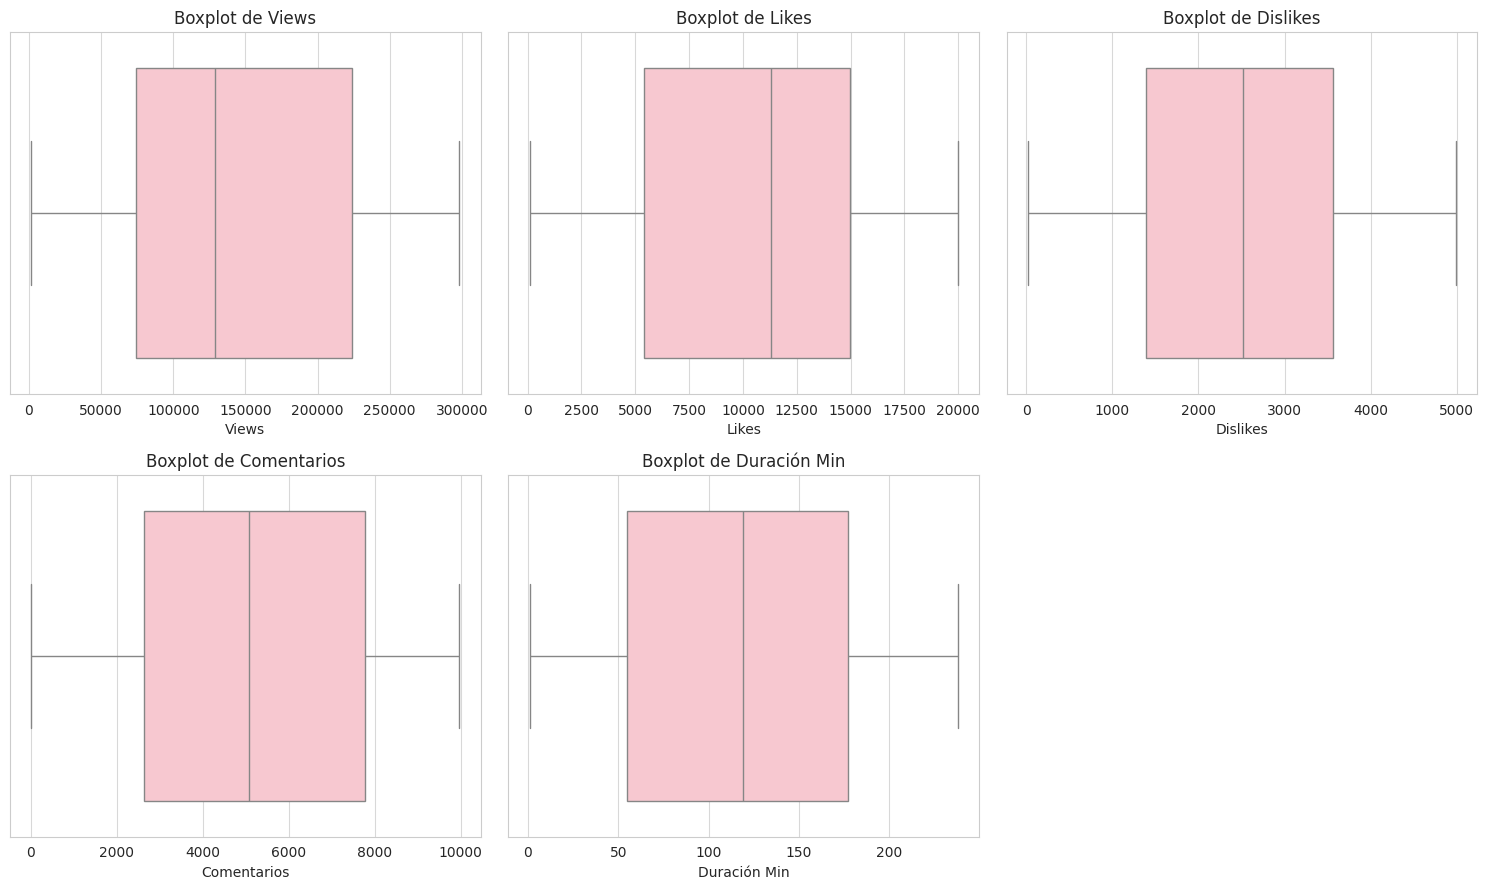

In [128]:
# Observar comportamiento cuartil final de los datos

plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df_copy[col], color='pink')
    plt.title(f'Boxplot de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.grid(axis='x', alpha=0.75)

plt.tight_layout()
plt.show()

In [129]:
df_copy

,video_id,título,categoría,views,likes,dislikes,comentarios,duración_min,fecha_publicación
0,1,título,música,129257,11299,21,8790,127,2024-07-02
1,2,título,películas,247904,15579,211,4775,63,2022-02-13
2,3,sin título,comedia,3073,14780,1095,9847,55,2016-07-06
3,4,título,gaming,268858,2691,4420,7614,78,2017-12-03
4,5,título,gaming,162893,16521,2294,6508,143,2023-11-24
...,...,...,...,...,...,...,...,...,...
302,163,título,gaming,224672,18981,720,3508,45,2021-04-04
303,106,título,películas,150272,11299,4605,6716,213,2021-09-04
305,6,título,películas,42160,10721,3547,9033,58,2025-08-27
306,97,título,deportes,13530,14437,2631,2629,158,2018-03-12


#### **SUSTITUCIÓN CORRECTA DE VALORES LIKES O DISLIKES**

In [130]:
# Ver total de likes mayores a las vistas

corrupted_likes_mask = df_copy['likes'] > df_copy['views']

In [131]:
# Ver total de dislikes mayores a las vistas

corrupted_dislikes_mask = df_copy['dislikes'] > df_copy['views']

In [132]:
# Ver total de likes y dislikes mayores a las vistas

corrupted_likes_dislikes_mask = (corrupted_likes_mask) & (corrupted_dislikes_mask)

In [133]:
# Cantidad de filas de dislikes mayores a views
len(df_copy[(corrupted_dislikes_mask)])

2

In [134]:
# Cantidad de filas de likes mayores a views
len(df_copy[(corrupted_likes_mask)])

13

In [135]:
# Cantidad de filas de likes y dislikes mayores a views
df_copy[corrupted_likes_dislikes_mask]

,video_id,título,categoría,views,likes,dislikes,comentarios,duración_min,fecha_publicación
80,81,título,educación,1691,14468,2948,7398,71,2015-06-14
164,165,título,gaming,2052,7215,3765,5548,126,2020-05-27


In [136]:
# Realizamos una suma para llenar las filas de likes y dislikes mayores a views
df_copy.loc[corrupted_likes_dislikes_mask, 'views'] = df_copy.loc[corrupted_likes_dislikes_mask, 'likes'] + df_copy.loc[corrupted_likes_dislikes_mask, 'dislikes']

In [137]:
# Realizamos una resta para llenar las filas de likes mayores a views
df_copy.loc[corrupted_likes_mask, 'likes'] = df_copy.loc[corrupted_likes_mask, 'views'] - df_copy.loc[corrupted_likes_mask, 'dislikes']

In [138]:
df_copy[df_copy['views'] < 0]

,video_id,título,categoría,views,likes,dislikes,comentarios,duración_min,fecha_publicación


In [139]:
df_copy[df_copy['likes'] < 0]

,video_id,título,categoría,views,likes,dislikes,comentarios,duración_min,fecha_publicación


In [140]:
df_copy[df_copy['dislikes'] < 0]

,video_id,título,categoría,views,likes,dislikes,comentarios,duración_min,fecha_publicación


In [141]:
df_copy

,video_id,título,categoría,views,likes,dislikes,comentarios,duración_min,fecha_publicación
0,1,título,música,129257,11299,21,8790,127,2024-07-02
1,2,título,películas,247904,15579,211,4775,63,2022-02-13
2,3,sin título,comedia,3073,1978,1095,9847,55,2016-07-06
3,4,título,gaming,268858,2691,4420,7614,78,2017-12-03
4,5,título,gaming,162893,16521,2294,6508,143,2023-11-24
...,...,...,...,...,...,...,...,...,...
302,163,título,gaming,224672,18981,720,3508,45,2021-04-04
303,106,título,películas,150272,11299,4605,6716,213,2021-09-04
305,6,título,películas,42160,10721,3547,9033,58,2025-08-27
306,97,título,deportes,13530,10899,2631,2629,158,2018-03-12


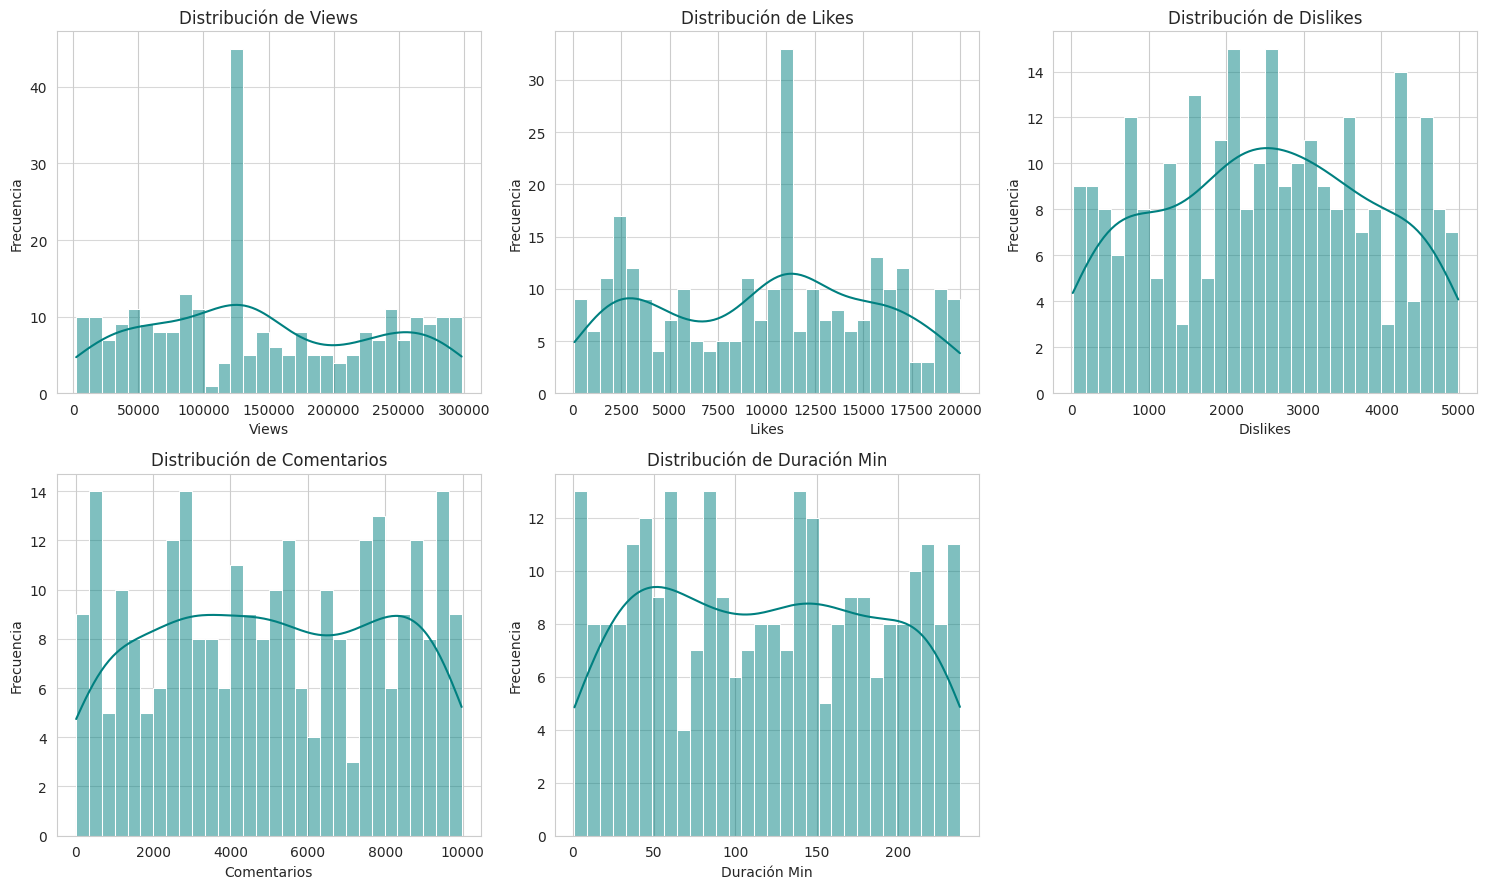

In [142]:
# Observar distribución de los datos

plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_copy[col], bins=30, kde=True, color='teal')
    plt.title(f'Distribución de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

### **CORRELACIÓN NUMÉRICA**

La **correlación numérica** es una medida estadística que **indica la fuerza y dirección de la relación lineal entre dos o más variables numéricas**. Puede utilizar el coeficiente de correlación de Pearson (el más común) para determinar la dirección (positiva, negativa, nula).

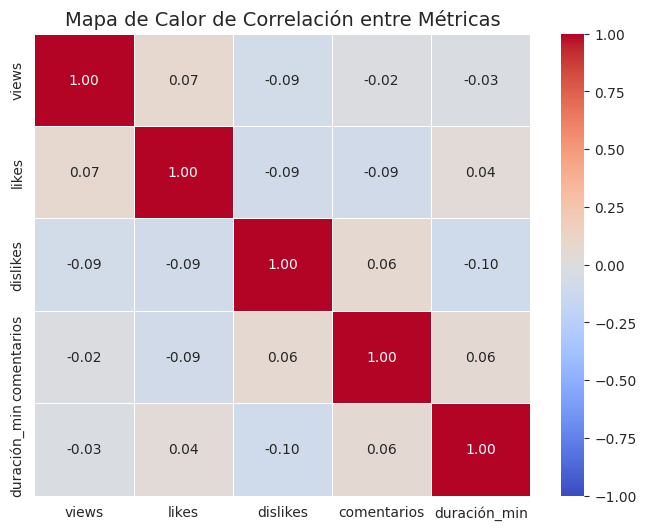

In [143]:
# Realizar matriz de correlación

corr_matrix = df_copy[['views', 'likes', 'dislikes', 'comentarios', 'duración_min']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Mapa de Calor de Correlación entre Métricas', fontsize=14)
plt.show()

# Los coeficientes de las intersecciones convergen en 0, no hay correlación

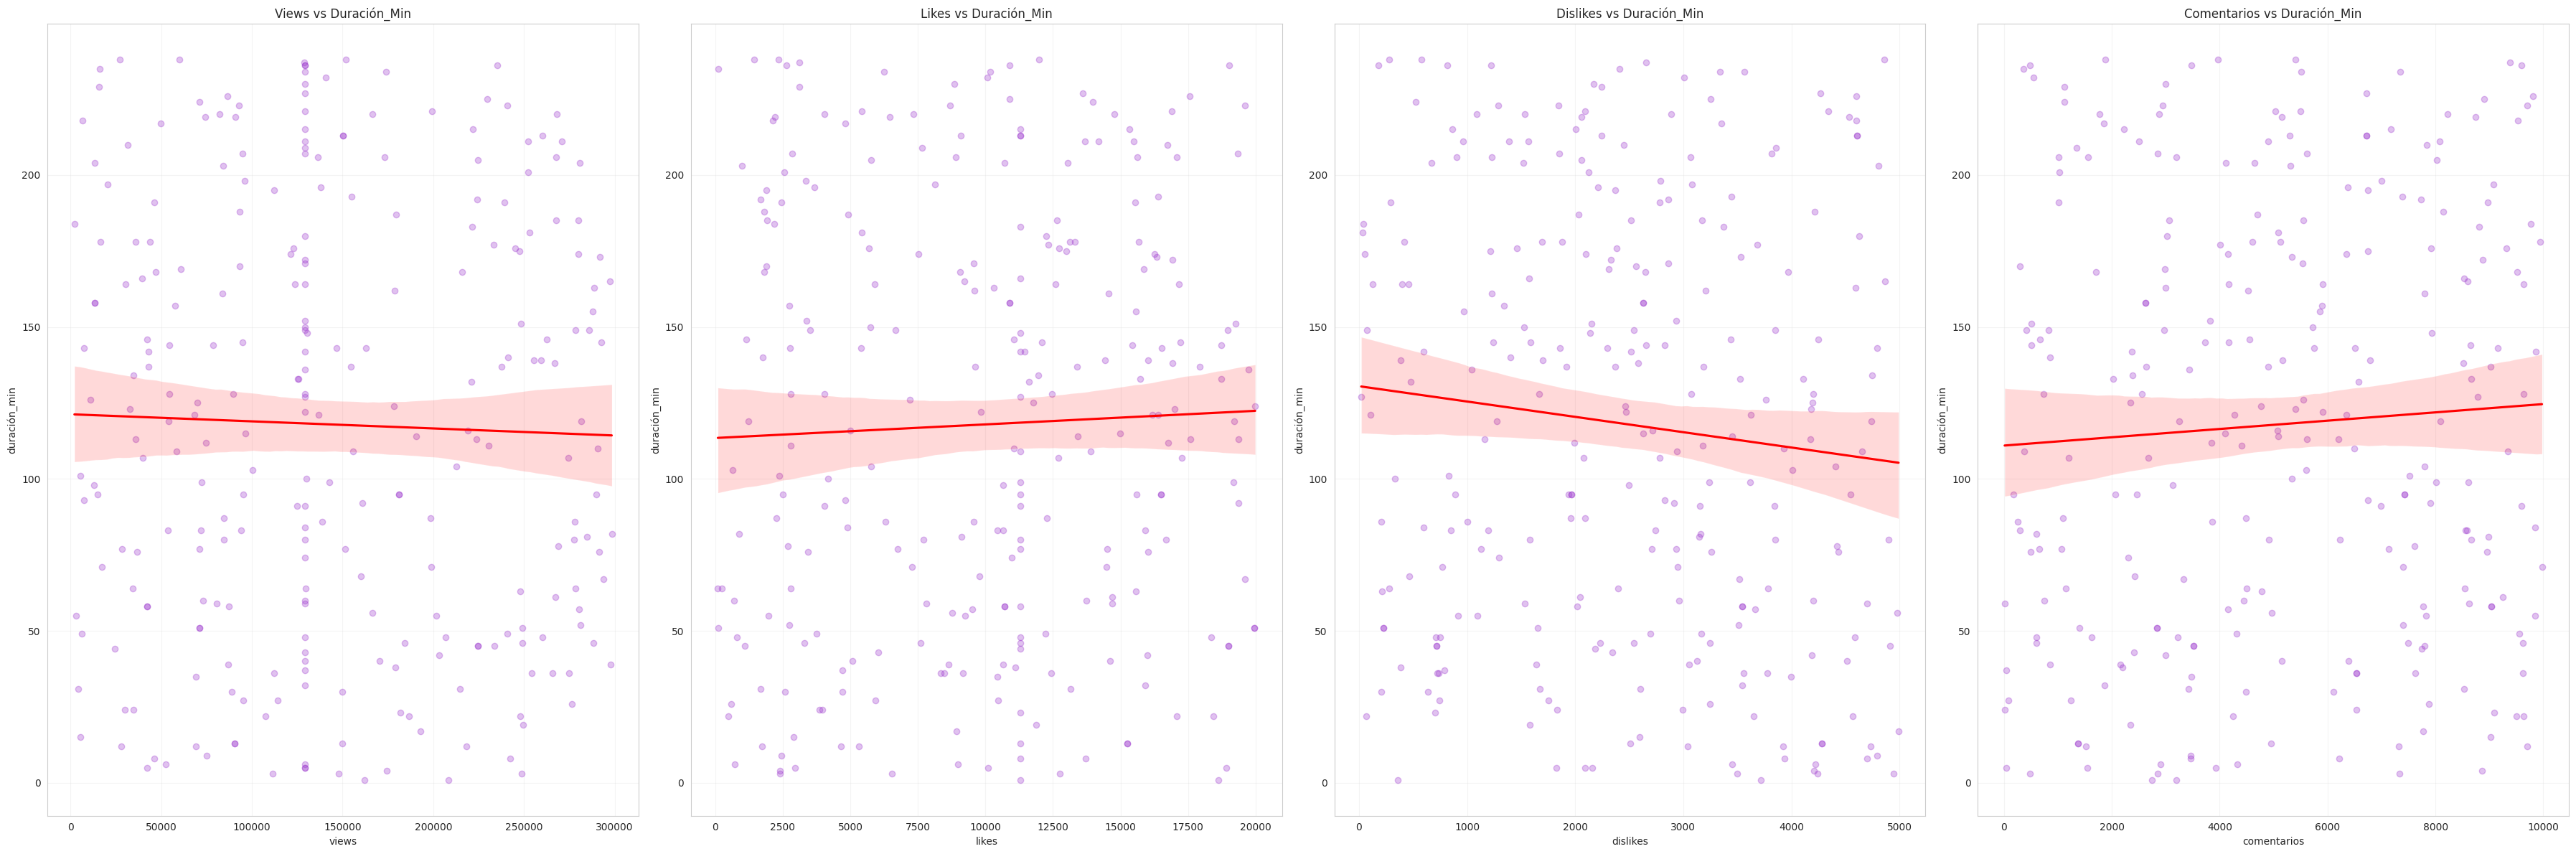

In [144]:
# Realizar correlaciones divididas

metricas = ['views', 'likes', 'dislikes', 'comentarios', 'duración_min']

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(36, 12))
axes = axes.flatten() # Aplanamos para iterar fácilmente

# Pares de comparación por

comparaciones = [
    ('views', 'duración_min'),
    ('likes', 'duración_min'),
    ('dislikes', 'duración_min'),
    ('comentarios', 'duración_min')
]

for i, (col_x, col_y) in enumerate(comparaciones):
    sns.regplot(ax=axes[i], data=df_copy, x=col_x, y=col_y,
                scatter_kws={'alpha':0.3, 'color':'darkorchid'},
                line_kws={'color':'red'})
    axes[i].set_title(f'{col_x.title()} vs {col_y.title()}')
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Al no haber correlaciones, los datos se muestran dispersos

#### **COMPARACIÓN POR CATEGÓRICA**

La **comparación por categórica** implica analizar cómo las variables numéricas se comportan o distribuyen a través de diferentes grupos o categorías. Este tipo de análisis es fundamental para entender: **distribuciones, tendencias y relaciones**

Para visualizar estas comparaciones, son muy útiles los **gráficos de barras**, donde se pueden mostrar las cantidades o promedios de una variable numérica para cada categoría, o los **diagramas de caja (boxplots)**, que revelan la distribución completa de los datos dentro de cada grupo, incluyendo la mediana, cuartiles y posibles valores atípicos.

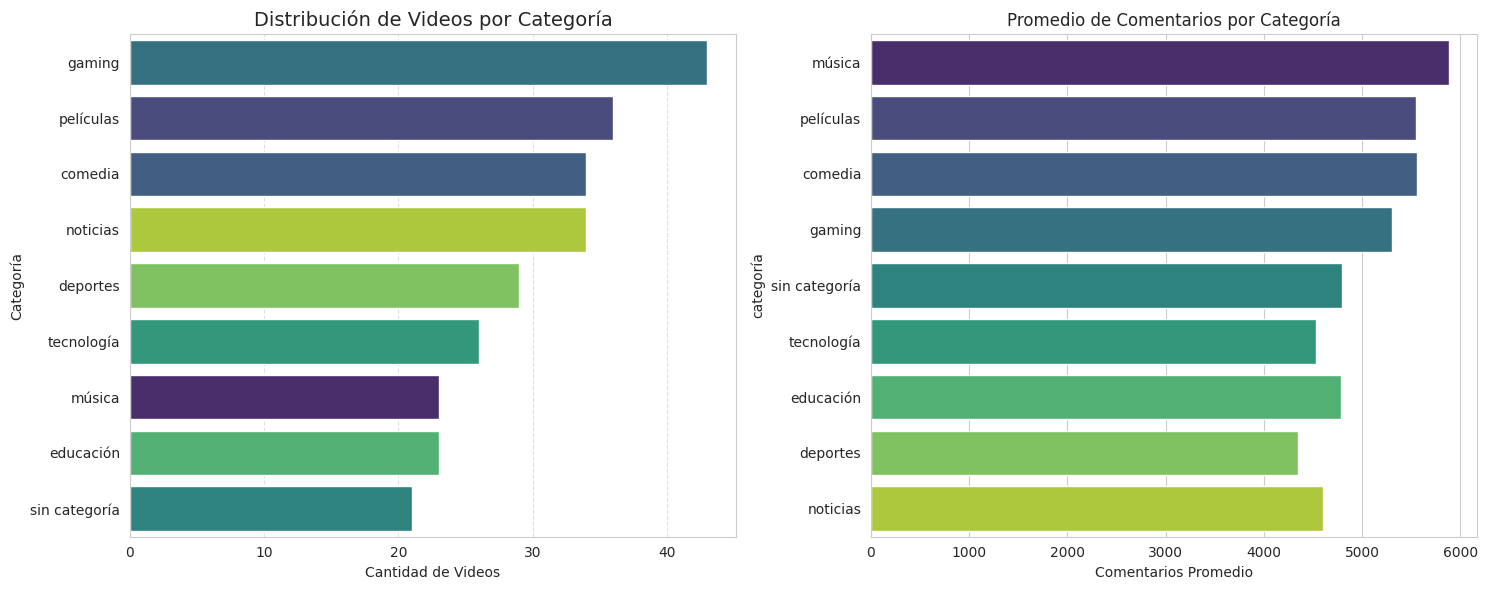

In [145]:
# Realizar gráficos de barras divididas

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
orden = df_copy['categoría'].value_counts().index # Ordenar de mayor a menor
sns.countplot(data=df_copy, y='categoría', order=orden, palette='viridis', hue='categoría', legend=False)
plt.title('Distribución de Videos por Categoría', fontsize=14)
plt.xlabel('Cantidad de Videos')
plt.ylabel('Categoría')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.barplot(data=df_copy, x='comentarios', y='categoría',
            estimator='mean', palette='viridis', errorbar=None, hue='categoría', legend=False)
plt.title('Promedio de Comentarios por Categoría')
plt.xlabel('Comentarios Promedio')

plt.tight_layout()
plt.show()

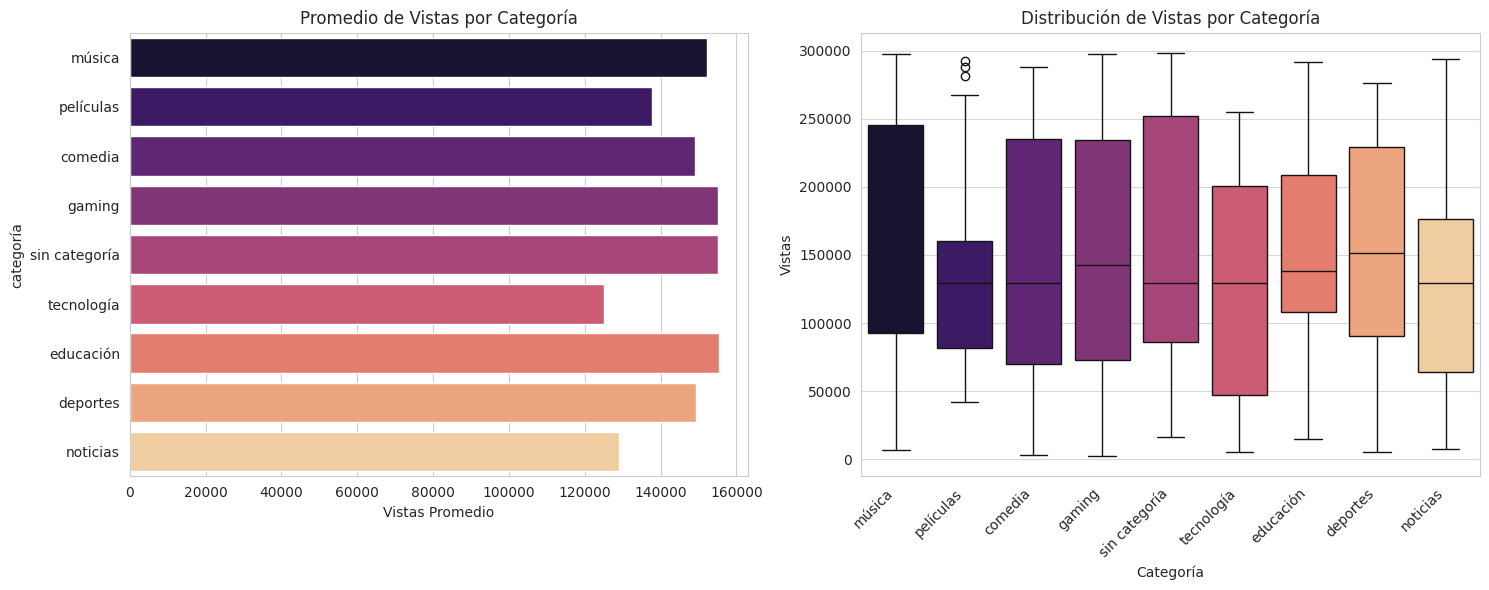

In [146]:
# Realizar gráfico de barras y caja divididos

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=df_copy, x='views', y='categoría',
            estimator='mean', palette='magma', errorbar=None, hue='categoría', legend=False)
plt.title('Promedio de Vistas por Categoría')
plt.xlabel('Vistas Promedio')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_copy, x='categoría', y='views', palette='magma', hue='categoría', legend=False)
plt.title('Distribución de Vistas por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Vistas')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

## **NARRATIVA VISUAL**

La **visualización narrativa** es la fusión estratégica entre la **claridad de los gráficos** y el **impacto del storytelling para comunicar mensajes** memorables. No se limita a exponer cifras, sino que construye un relato donde los datos actúan como evidencia para guiar a la audiencia hacia una conclusión clara.

Al conectar puntos de datos con una estructura narrativa, se logra captar la atención emocional y lógica del espectador. Esta técnica transforma estadísticas frías en una historia coherente, facilitando la comprensión de tendencias complejas y asegurando que los hallazgos clave impulsen una toma de decisiones informada.

### **PROPORCIÓN DE DATOS A MOSTRAR**

In [147]:
# Definir variables para la agrupación

categoria = lambda x: 'Sin Categoría' if x == 'sin categoría' else 'Con Categoría'
df_copy['agrupacion_cat'] = df_copy['categoría'].apply(categoria)
pie_data = df_copy['agrupacion_cat'].value_counts()

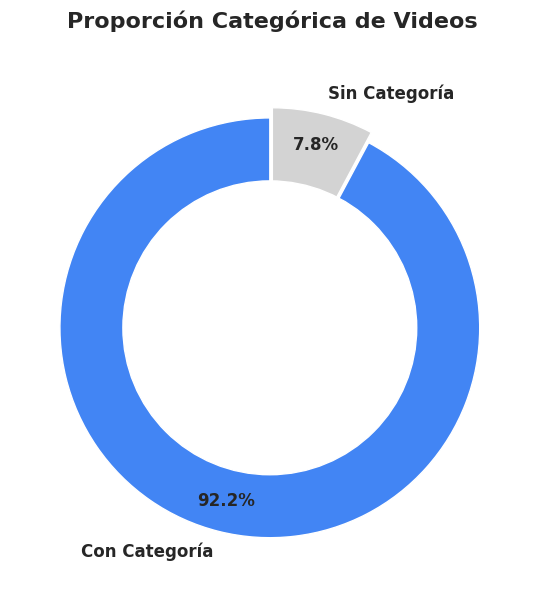

In [148]:
# Realizar gráfico de dona

colors_pie = ['#4285F4', '#D3D3D3'] # Azul = "Con Categoría", Gris = "Sin Categoría"
explode_val = 0.05 # Valor de separación

# Gráfico de pastel

plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(pie_data,
                                   labels=pie_data.index,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=colors_pie,
                                   textprops={'fontsize': 12, 'fontweight': 'bold'},
                                   pctdistance=0.85, # Mueve el porcentaje hacia afuera
                                   explode=(explode_val, 0)) # Resalta ligeramente la porción principal

# Círculo blanco central (estilo moderno)

theta1, theta2 = wedges[0].theta1, wedges[0].theta2
center_angle = np.deg2rad((theta1 + theta2) / 2) # Obtención el ángulo medio

cx = explode_val * np.cos(center_angle) # Se Calcula nueva posición con trigonometría
cy = explode_val * np.sin(center_angle)

centre_circle = plt.Circle((cx, cy), 0.70, fc='white') # Se dibuja el circulo
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proporción Categórica de Videos', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### **DISTRIBUCIÓN DE VÍDEOS POR CATEGORÍA**

In [149]:
# Definir variables

df_filtrado = df_copy[df_copy['categoría'] != 'sin categoría']
counts = df_filtrado['categoría'].value_counts()
order = counts.index
values = counts.values

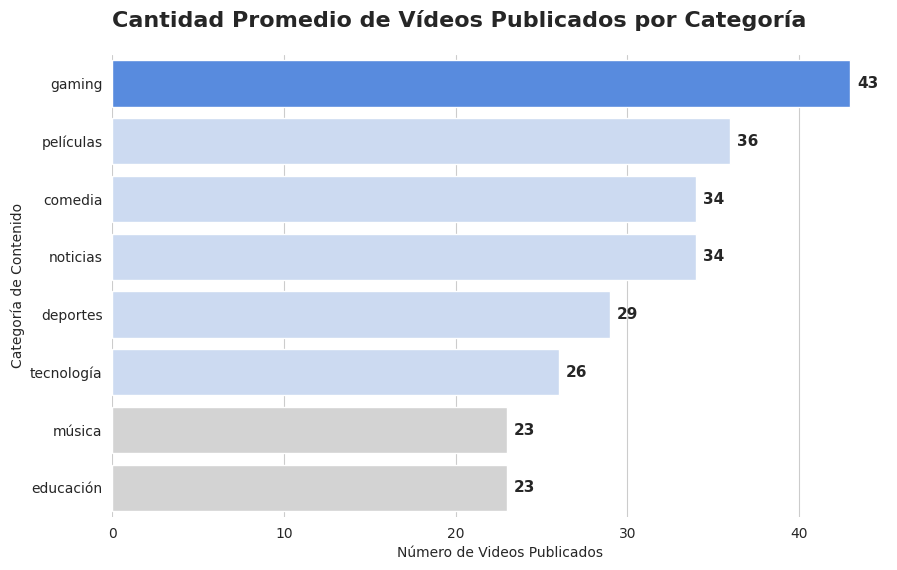

In [150]:
# Realizar gráfico de barras

colors = ['#4285F4' if v == values.max() else '#D3D3D3' if v == values.min() else '#C6D9F7' for v in values]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x=values, y=order, palette=colors, hue=order, legend=False)

for p in ax.patches: # Etiquetas de datos
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=11, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Cantidad Promedio de Vídeos Publicados por Categoría', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Número de Videos Publicados')
plt.ylabel('Categoría de Contenido')
sns.despine(left=True, bottom=True)
plt.show()

### **PROMEDIO DE VISTAS POR CATEGORÍA**

In [151]:
# Definir variables

vistas_mean = df_copy.groupby('categoría')['views'].mean().sort_values(ascending=False)
colors_vistas = ['#4285F4' if v == vistas_mean.max() else '#D3D3D3' if v == vistas_mean.min() else '#C6D9F7' for v in vistas_mean]

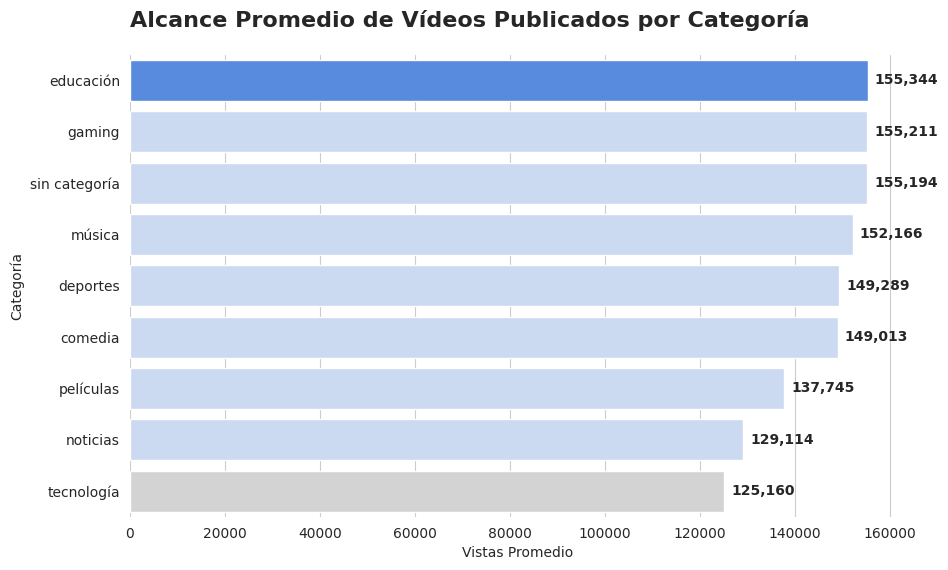

In [152]:
# Realizar gráfico de barras

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax1 = sns.barplot(x=vistas_mean.values, y=vistas_mean.index, palette=colors_vistas, hue=vistas_mean.index, legend=False)

for p in ax1.patches: # Etiquetas y estética
    ax1.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Alcance Promedio de Vídeos Publicados por Categoría', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Vistas Promedio')
plt.ylabel('Categoría')
sns.despine(left=True, bottom=True)
plt.show()

### **PROMEDIO DE COMENTARIOS POR CATEGORÍA**

In [153]:
# Definir variables

coments_mean = df_copy.groupby('categoría')['comentarios'].mean().sort_values(ascending=False)
colors_coments = ['#4285F4' if v == coments_mean.max() else '#D3D3D3' if v == coments_mean.min() else '#C6D9F7' for v in coments_mean]

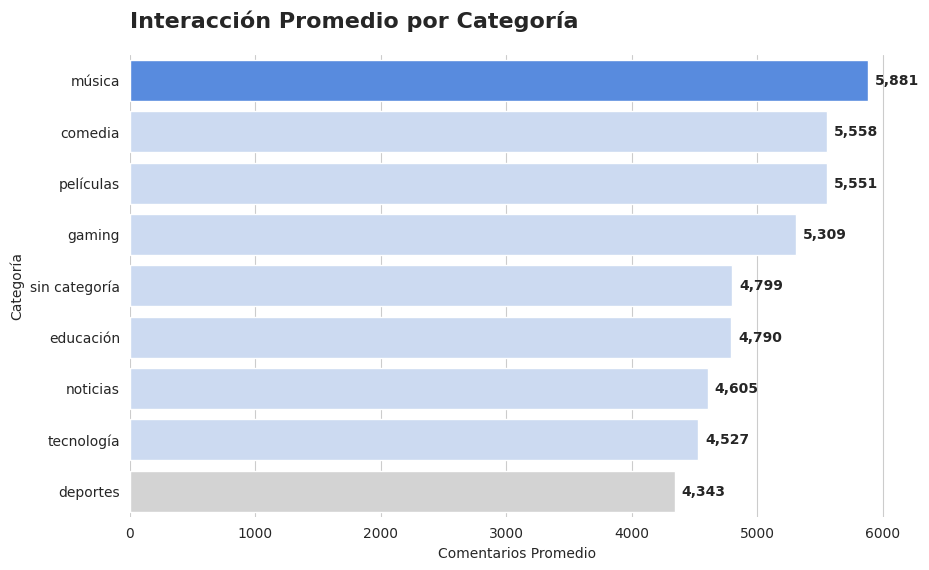

In [154]:
# Realizar gráfico de barras

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax2 = sns.barplot(x=coments_mean.values, y=coments_mean.index, palette=colors_coments, hue=coments_mean.index, legend=False)

for p in ax2.patches: # Etiquetas y estética
    ax2.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Interacción Promedio por Categoría', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Comentarios Promedio')
plt.ylabel('Categoría')
sns.despine(left=True, bottom=True)
plt.show()

## **CHALLENGE: EXPLORACIÓN DE DATOS AIRBNB CDMX**

Una vez visto el ***Hands - On: Exploración de datos***, se presentan las siguientes actividades para que el alumnado pueda repasar y reforzar lo aprendido dentro de la clase.

Para este notebook, se hará uso del siguiente dataset: [enlace](https://drive.google.com/file/d/1HKCV2jFnumpJ1YNFI5cn6wgT2tEiKKfK/view?usp=drive_link)

Dentro de la siguiente dinámica, **se realizará un análisis exploratorio profundo sobre el catálogo de alojamientos de Airbnb en la Ciudad de México** para detectar patrones de comportamiento, valores atípicos y relaciones entre variables. Se hará uso de **herramientas estadísticas, técnicas de detección de outliers y narrativa visual** a través del dataset **"airbnb_clean"**.

Donde los análisis a realizar son:

* **Detección y tratamiento de valores atípicos mediante el rango intercuartílico**.
* **Identificación de relaciones lineales entre variables numéricas**.
* **Comunicación de hallazgos a través de narrativa visual por categoría**.

**IMPORTANTE:** Para su revisión, **es indispensable que los apartados anteriores se encuentren llenados con el código visto durante la sesión.**

### **INSTRUCCIONES:**

**1. Importaciones y análisis de resumen estadístico:**

* Carga las bibliotecas de Pandas, Numpy, Seaborn y Matplotlib.pyplot.
* Carga el archivo *airbnb_clean.csv*.
* Obtén el resumen estadístico de los datos.

In [155]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [156]:
# Importar datos
ruta_colab = '/content/drive/MyDrive/AnalisisDatos/Assets/airbnb_clean.csv'
df_airbnb = pd.read_csv(ruta_colab)

df_yt

,video_id,título,categoría,views,likes,dislikes,comentarios,duración_min,fecha_publicación
0,1,título,música,129257,11299,21,8790,127,2024-07-02
1,2,título,películas,247904,15579,211,4775,63,2022-02-13
2,3,sin título,comedia,3073,14780,1095,9847,55,2016-07-06
3,4,título,gaming,268858,2691,4420,7614,78,2017-12-03
4,5,título,gaming,162893,16521,2294,6508,143,2023-11-24
...,...,...,...,...,...,...,...,...,...
303,106,título,películas,150272,11299,4605,6716,213,2021-09-04
304,131,título,tecnología,25407,9999999,2437,4498,137,2025-07-18
305,6,título,películas,42160,10721,3547,9033,58,2025-08-27
306,97,título,deportes,13530,14437,2631,2629,158,2018-03-12


In [157]:
df_airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27051 entries, 0 to 27050
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              27051 non-null  int64  
 1   name                            27051 non-null  object 
 2   host_id                         27051 non-null  int64  
 3   host_name                       27051 non-null  object 
 4   neighbourhood                   27051 non-null  object 
 5   latitude                        27051 non-null  float64
 6   longitude                       27051 non-null  float64
 7   room_type                       27051 non-null  object 
 8   price                           27051 non-null  float64
 9   minimum_nights                  27051 non-null  int64  
 10  number_of_reviews               27051 non-null  int64  
 11  last_review                     27051 non-null  object 
 12  reviews_per_month               

In [158]:
# Ver resumen estadístico
columnas_numericas = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month']
df_airbnb[columnas_numericas].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month
count,27051.000000,27051.000000,27051.000000,27051.000000
mean,1695.489483,4.580866,53.777679,1.621652
std,12352.097771,24.784605,85.143043,2.219818
min,61.000000,1.000000,0.000000,0.000000
25%,700.000000,1.000000,4.000000,0.210000
50%,1039.000000,2.000000,21.000000,1.000000
75%,1484.000000,2.000000,69.000000,2.370000
max,900000.000000,1125.000000,1434.000000,119.460000


**2. Análisis de distribución y filtrado de outliers:**

* Genera un histograma y diagrama de caja sobre la columna `price`.
* Calcula la cantidad de registros con los que cuenta el dataframe.
* Calcula el rango intercuartílico y filtra el dataframe con los registros dentro de los límites.
* Calcula la cantidad y proporción de registros finales y grafica su diagrama de caja.

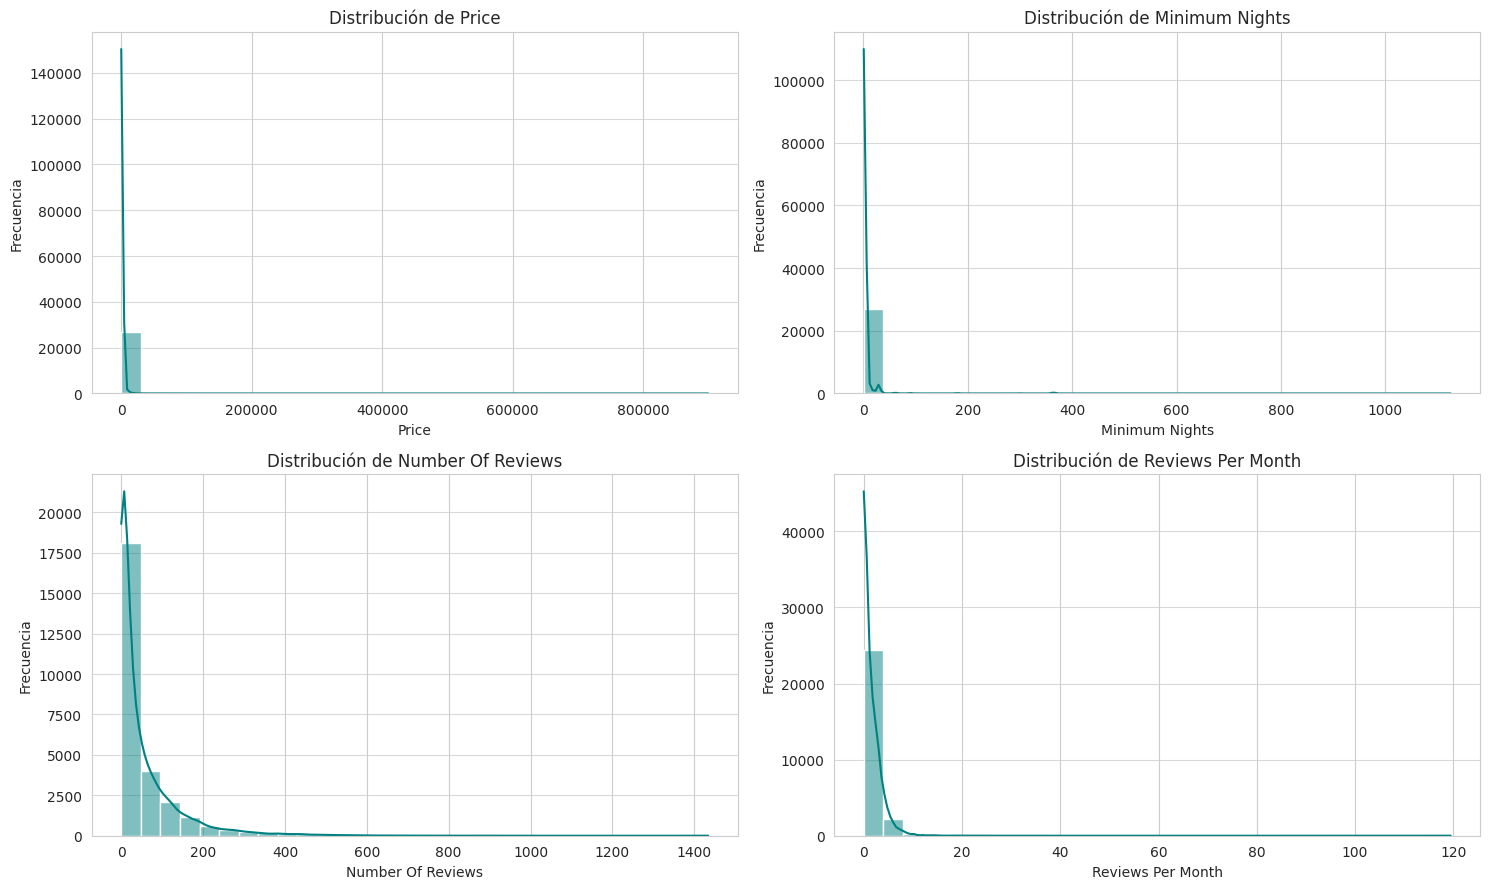

In [159]:
# Observar distribución y comportamiento cuartil de los datos
plt.figure(figsize = (15, 9))

for i, col in enumerate(columnas_numericas, 1):
  plt.subplot(2, 2, i)
  sns.histplot(df_airbnb[col], bins=30, kde=True, color='teal')
  plt.title(f'Distribución de {col.replace("_", " ").title()}')
  plt.xlabel(col.replace("_", " ").title())
  plt.ylabel('Frecuencia')
  plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()


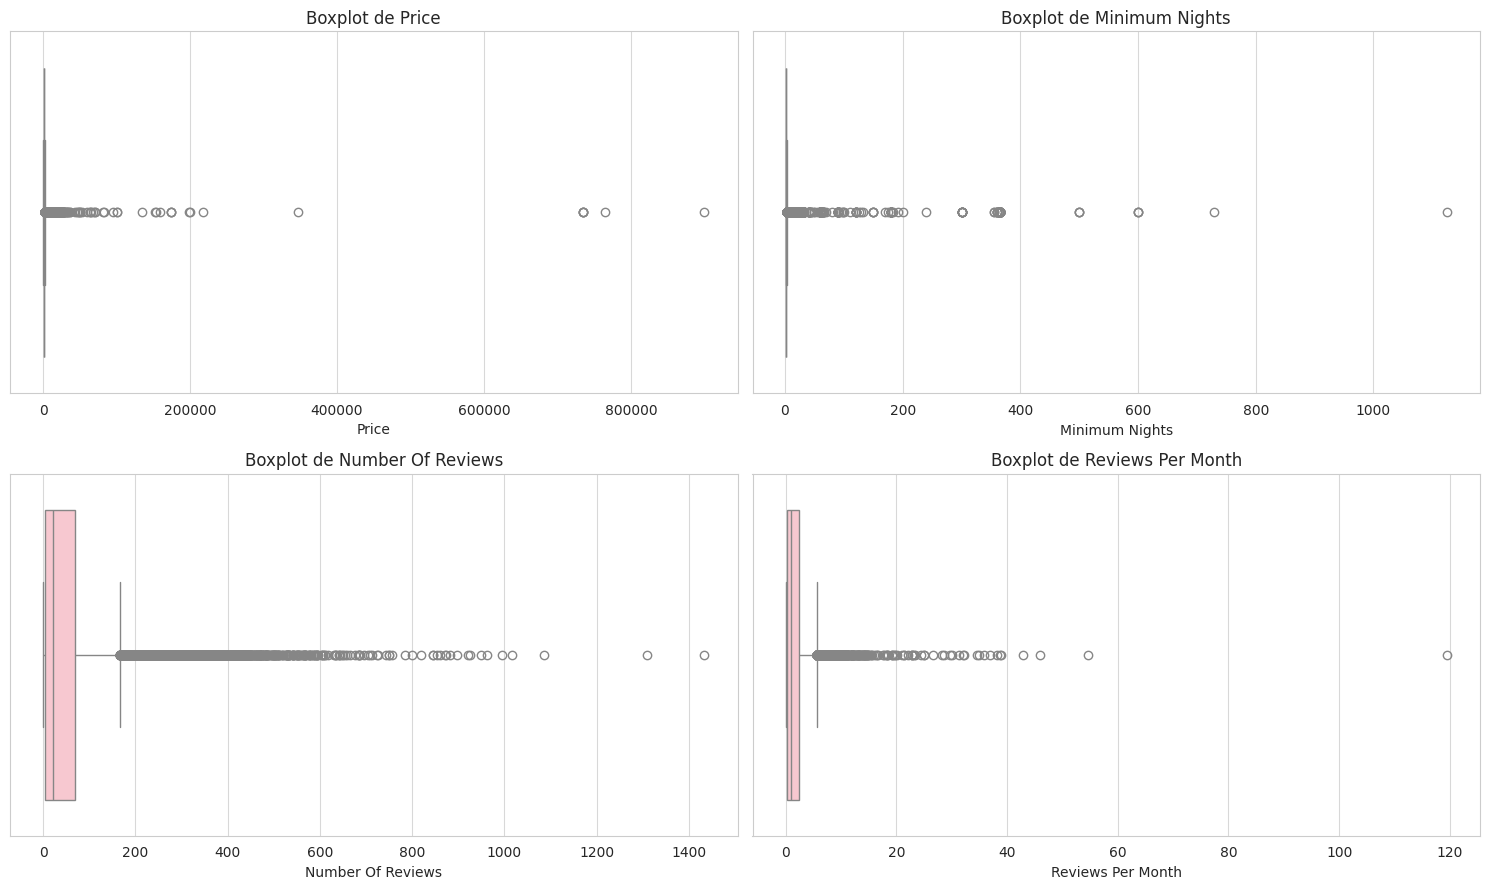

In [160]:
plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df_airbnb[col], color='pink')
    plt.title(f'Boxplot de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.grid(axis='x', alpha=0.75)

plt.tight_layout()
plt.show()

In [161]:
# Ver cantidad de registros iniciales
print(f'Cantidad de datos iniciales: {len(df_airbnb)}')

Cantidad de datos iniciales: 27051


In [162]:
# Calculo del IQR
df_copy = df_airbnb.copy() # Preservar el dataset haciendo una copia

for col in columnas_numericas:

  Q1 = df_copy[col].quantile(0.25) # Primer cuartil
  Q3 = df_copy[col].quantile(0.75) # Tercer cuartil
  IQR = Q3 - Q1 # Rango intercuartilico

  lim_inf_iqr = Q1 - 1.5 * IQR # Limite inferior
  lim_sup_iqr = Q3 + 1.5 * IQR # Limite superior

  cant_inicial = len(df_copy)
  # Filtro de los datos dentro de los limites
  df_copy = df_copy[(df_copy[col] >= lim_inf_iqr) & (df_copy[col] <= lim_sup_iqr)]
  cant_final = len(df_copy)

  print(f"Columna '{col}': Se eliminaron {cant_inicial - cant_final} registros.")


Columna 'price': Se eliminaron 2310 registros.
Columna 'minimum_nights': Se eliminaron 3199 registros.
Columna 'number_of_reviews': Se eliminaron 1642 registros.
Columna 'reviews_per_month': Se eliminaron 731 registros.


In [163]:
# Ver cantidad y proporción con la cantidad inicial
prop_datos_finales = round((len(df_copy) / len(df_airbnb) * 100.0), 2)

print(f'Cantidad de datos finales: {len(df_copy)}')
print(f'Los datos finales representan el {prop_datos_finales}% de los datos iniciales')

Cantidad de datos finales: 19169
Los datos finales representan el 70.86% de los datos iniciales


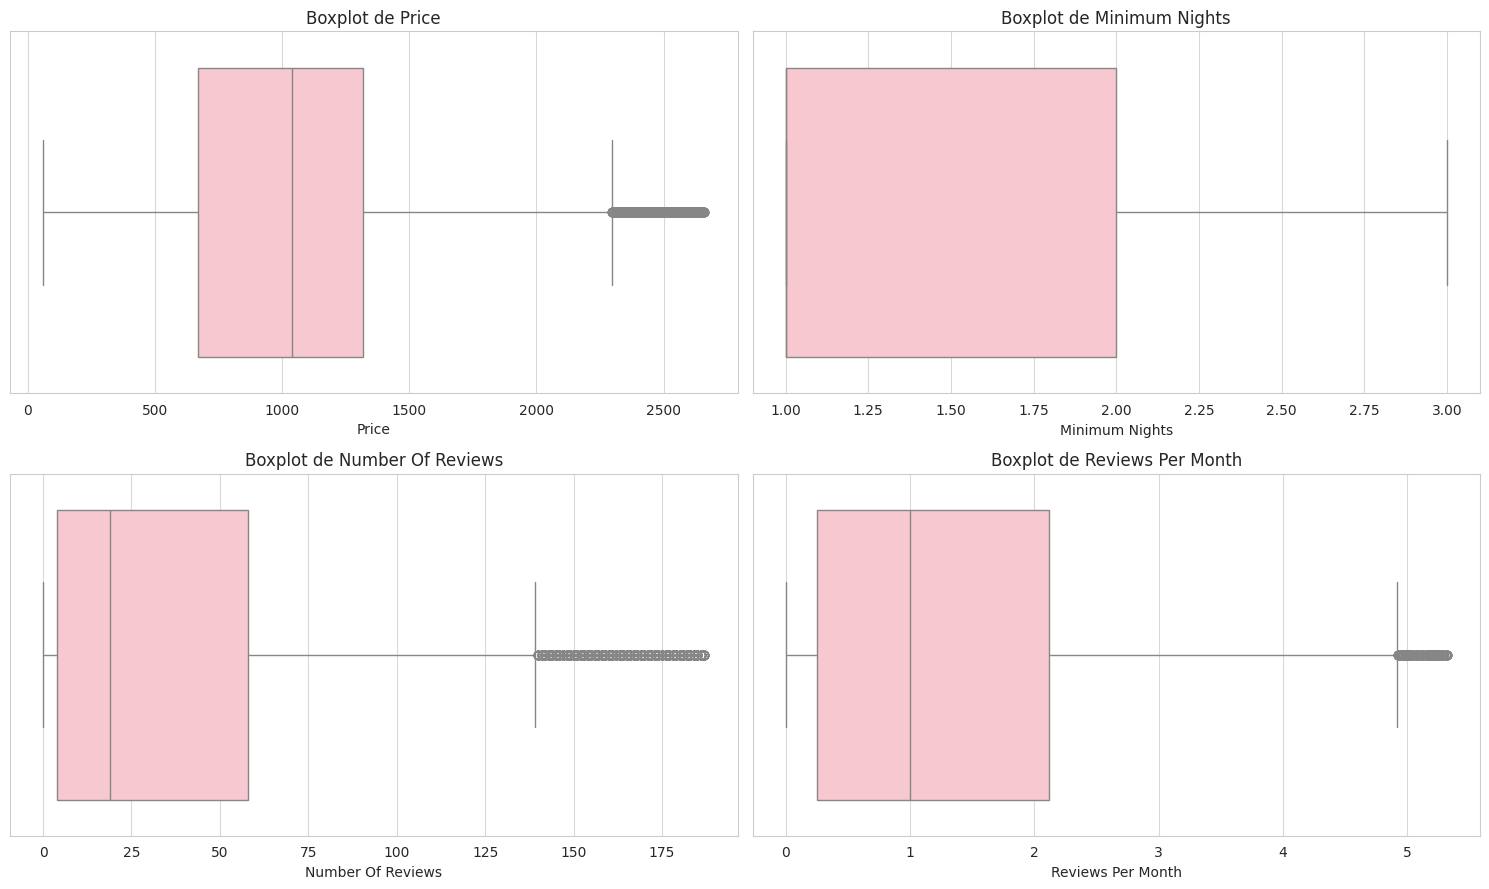

In [164]:
# Observar comportamiento cuartil final de los datos
plt.figure(figsize=(15, 9))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df_copy[col], color='pink')
    plt.title(f'Boxplot de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.grid(axis='x', alpha=0.75)

plt.tight_layout()
plt.show()

In [165]:
df_copy[columnas_numericas].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month
count,19169.000000,19169.000000,19169.000000,19169.000000
mean,1059.532266,1.579686,38.098962,1.351911
std,526.622901,0.706240,44.591466,1.282423
min,61.000000,1.000000,0.000000,0.000000
25%,668.000000,1.000000,4.000000,0.250000
50%,1039.000000,1.000000,19.000000,1.000000
75%,1319.000000,2.000000,58.000000,2.120000
max,2660.000000,3.000000,187.000000,5.320000


**3. Análisis de correlaciones:**

* Genera una matriz de correlación sobre las columnas numéricas del dataframe.
* Selecciona las variables numéricas más representativas.
* Realiza correlaciones divididas por categoría segmentadas por la columna `room_type`.

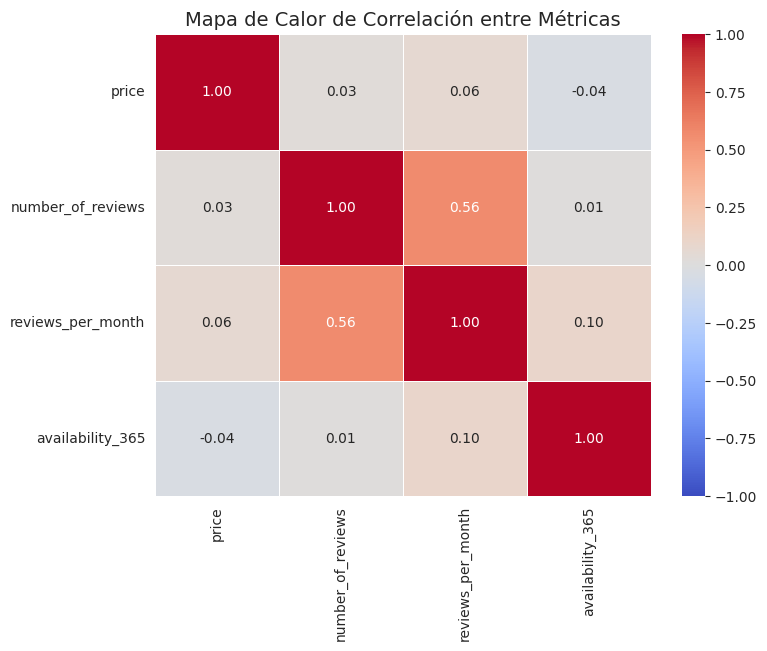

In [166]:
# Realizar matriz de correlación
corr_matrix = df_copy[['price', 'number_of_reviews', 'reviews_per_month', 'availability_365']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Mapa de Calor de Correlación entre Métricas', fontsize=14)
plt.show()

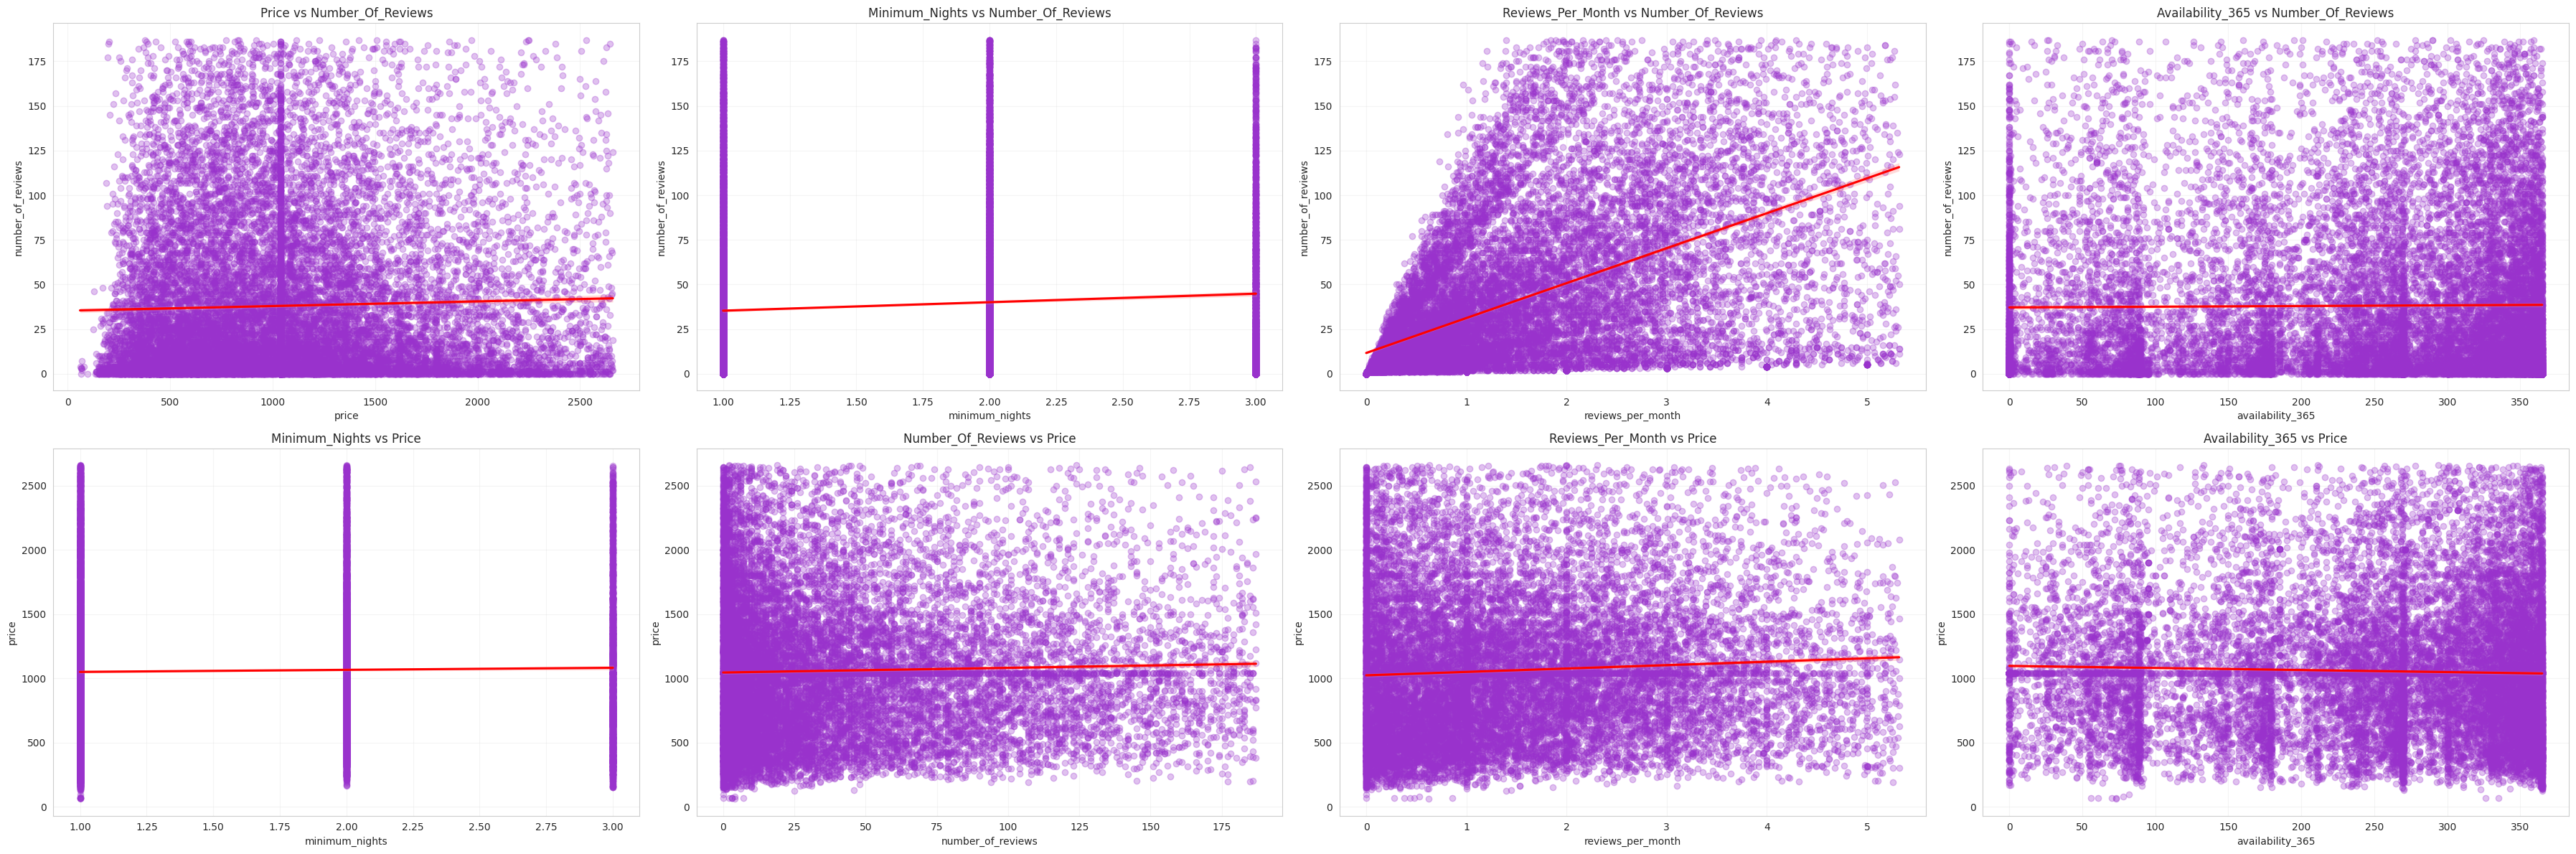

In [167]:
# Realizar correlaciones divididas

metricas = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(36, 12))
axes = axes.flatten() # Aplanamos para iterar fácilmente

# Pares de comparación por

comparaciones = [
    ('price', 'number_of_reviews'),
    ('minimum_nights', 'number_of_reviews'),
    ('reviews_per_month', 'number_of_reviews'),
    ('availability_365', 'number_of_reviews'),
    ('minimum_nights', 'price'),
    ('number_of_reviews', 'price'),
    ('reviews_per_month', 'price'),
    ('availability_365', 'price')

]

for i, (col_x, col_y) in enumerate(comparaciones):
    sns.regplot(ax=axes[i], data=df_copy, x=col_x, y=col_y,
                scatter_kws={'alpha':0.3, 'color':'darkorchid'},
                line_kws={'color':'red'})
    axes[i].set_title(f'{col_x.title()} vs {col_y.title()}')
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

**4. Regresión lineal simple:**

* Define como variable independiente `reviews_per_month` y como dependiente `number_of_reviews_ltm`.
* Calcula los coeficientes para determinar la ecuación del modelo de regresión lineal simple.
* Ajusta el modelo de regresión lineal con descenso de gradiente y determina la nueva ecuación.
* Visualizar el modelo de regresión lineal ajustada y la curva de perdidas.
* Calcula la reducción del error desde la primera hasta la última época.


In [168]:
# Cálculo de la regresión lineal simple
x = df_copy["reviews_per_month"].dropna()
y = df_copy["number_of_reviews_ltm"].dropna()
linear_regression = np.polyfit(x, y, deg=1)
beta, alpha = linear_regression
print(f"y={beta}, x + {alpha}")

y=9.517789031238271, x + 0.11411633320240543


In [169]:
# Calculo del descenso de gradiente
steps = 00.0001
theta_0 = 0
theta_1 = 0

perdida = []
iteraciones = 100

for i in range(iteraciones):
  y_pred = theta_1 * x + theta_0
  error = ((y - y_pred)**2).mean()
  perdida.append(error)

  d_theta_0 = (2 / len(x)) * np.sum(y_pred - y)
  d_theta_1 = (2 / len(x)) * np.sum((y_pred - y) * x)

  theta_0 = theta_0 - steps * d_theta_0
  theta_1 = theta_1 - steps * d_theta_1

print(f"y = {theta_1} x = {theta_0}")

y = 0.6384199287472779 x = 0.24846995201473565


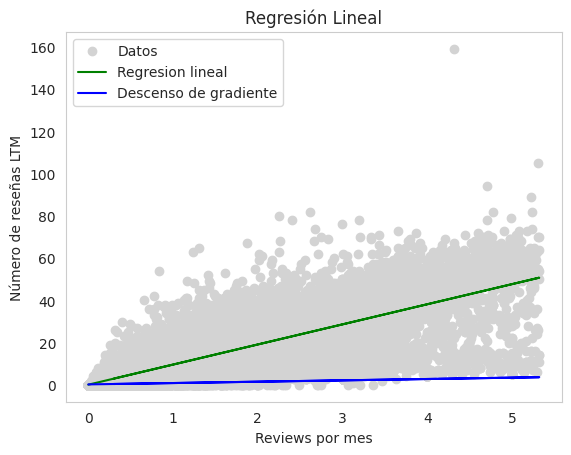

In [170]:
# Visualizar regresión lineal y perdidas
plt.plot(x, y, "o", color = "lightgray", label="Datos")
plt.plot(x, beta * x + alpha, color = "green", label = "Regresion lineal")
plt.plot(x, theta_1 * x + theta_0, color = "blue", label = "Descenso de gradiente")
plt.xlabel("Reviews por mes")
plt.ylabel("Número de reseñas LTM")
plt.title("Regresión Lineal")
plt.legend()
plt.grid()
plt.show()

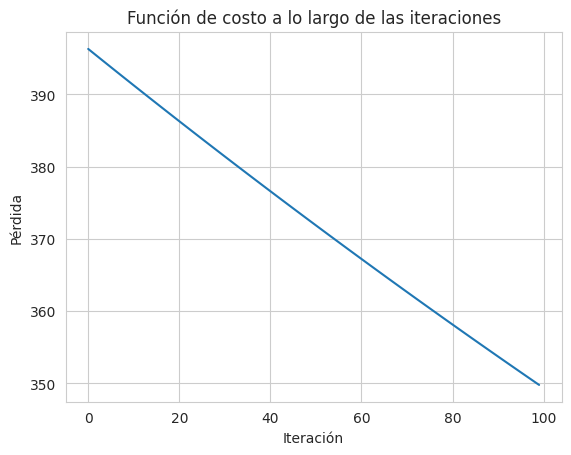

Reducción del error de la primera a la última época: 46.51%


In [171]:
# Registro final de perdida
plt.plot(perdida)
plt.xlabel("Iteración")
plt.ylabel("Pérdida")
plt.title("Función de costo a lo largo de las iteraciones")
plt.grid(True)
plt.show()

#Calcula la reducción del error desde la primera hasta la última época.
error_reduction = perdida[0] - perdida[-1]
print(f"Reducción del error de la primera a la última época: {error_reduction:.2f}%")

**5. Comparación por categoría:**

* Utiliza un gráfico de barras para mostrar el precio promedio por tipo de habitación.
* Utiliza un diagrama de caja para visualizar la distribución del precio por tipo de habitación.
* Agrupa el dataframe por la columna `room_type` y calcula el conteo de alojamientos.
* Utiliza un gráfico de dona que muestre el porcentaje de cada categoría.

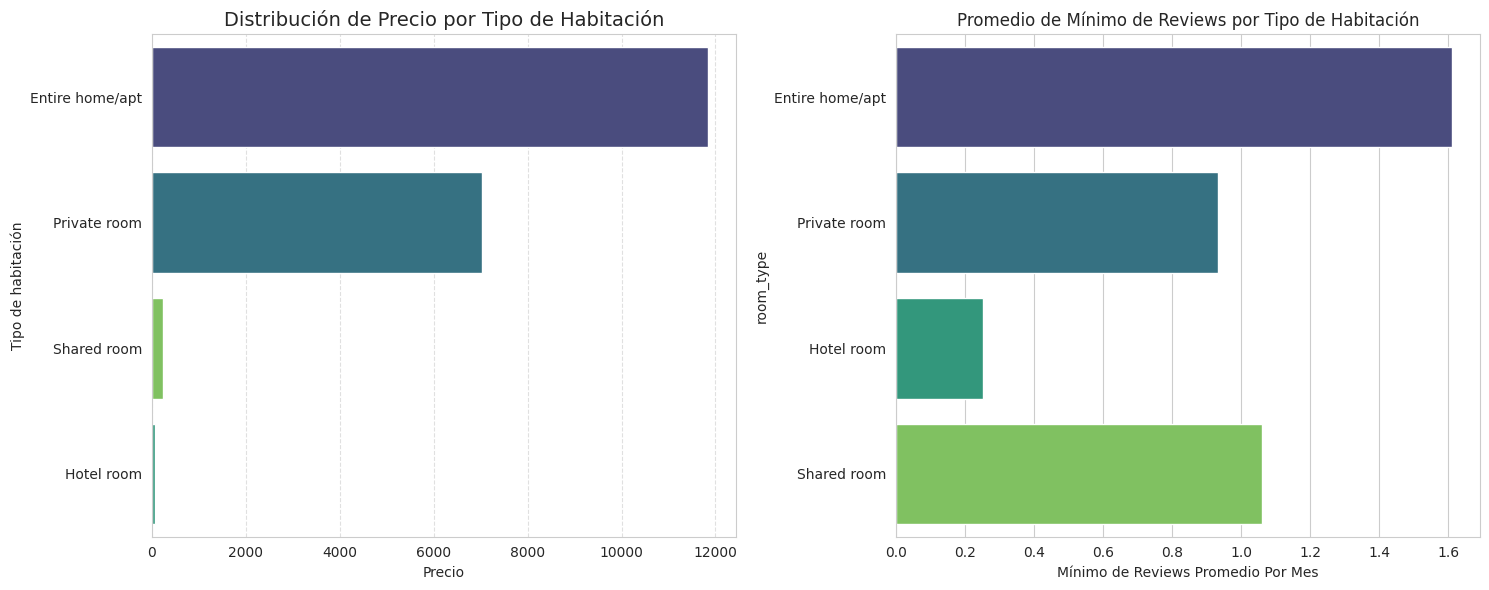

In [172]:
# Realizar gráficos de barras divididas
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
orden = df_copy['room_type'].value_counts().index # Ordenar de mayor a menor
sns.countplot(data=df_copy, y='room_type', order=orden, palette='viridis', hue='room_type', legend=False)
plt.title('Distribución de Precio por Tipo de Habitación', fontsize=14)
plt.xlabel('Precio')
plt.ylabel('Tipo de habitación')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.barplot(data=df_copy, x='reviews_per_month', y='room_type',
            estimator='mean', palette='viridis', errorbar=None, hue='room_type', legend=False)
plt.title('Promedio de Mínimo de Reviews por Tipo de Habitación')
plt.xlabel('Mínimo de Reviews Promedio Por Mes')

plt.tight_layout()
plt.show()

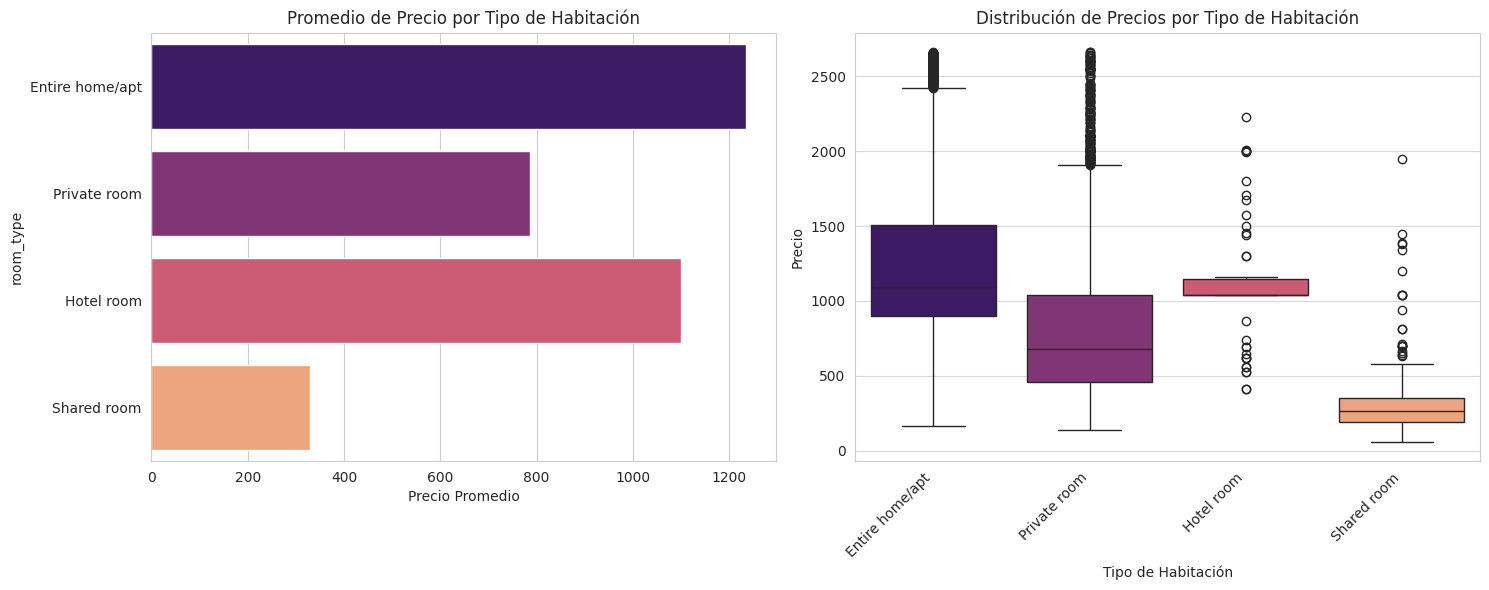

In [173]:
# Realizar gráfico de barras y caja divididos
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=df_copy, x='price', y='room_type',
            estimator='mean', palette='magma', errorbar=None, hue='room_type', legend=False)
plt.title('Promedio de Precio por Tipo de Habitación')
plt.xlabel('Precio Promedio')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_copy, x='room_type', y='price', palette='magma', hue='room_type', legend=False)
plt.title('Distribución de Precios por Tipo de Habitación')
plt.xlabel('Tipo de Habitación')
plt.ylabel('Precio')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

In [174]:
# Definir variables para la agrupación
categoria = lambda x: 'Otros' if x != 'Entire home/apt' and x != 'Private room' else x
df_copy['agrupacion_tipo_hab'] = df_copy['room_type'].apply(categoria)
pie_data = df_copy['agrupacion_tipo_hab'].value_counts()

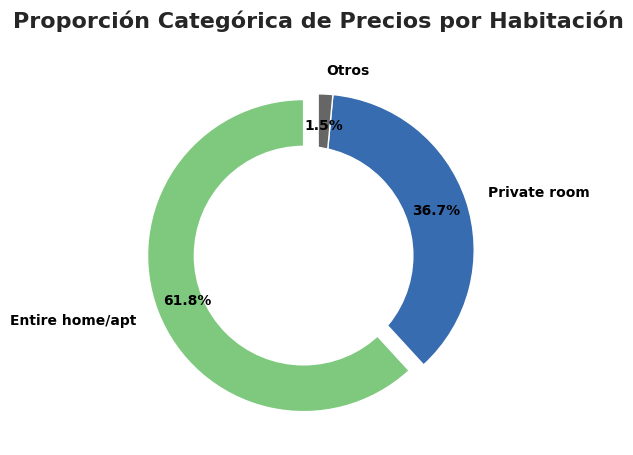

In [175]:
# Realizar gráfico de dona
colors_pie = plt.cm.Accent(np.linspace(0, 1, len(pie_data))) # Colores
explode_val = 0.1 # Valor de separación

# Gráfico de pastel
plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(pie_data,
                                   labels=pie_data.index,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=colors_pie,
                                   textprops={'fontsize': 10, 'fontweight': 'bold', 'color': 'black'}, # Styling for category labels
                                   pctdistance=0.8,
                                   labeldistance=1.15,
                                   explode=(explode_val, 0, 0)) # Resalta ligeramente la porción principal

# Círculo blanco central (estilo moderno)

theta1, theta2 = wedges[0].theta1, wedges[0].theta2
center_angle = np.deg2rad((theta1 + theta2) / 2) # Obtención el ángulo medio

cx = explode_val * np.cos(center_angle) # Se Calcula nueva posición con trigonometría
cy = explode_val * np.sin(center_angle)

centre_circle = plt.Circle((cx, cy), 0.70, fc='white') # Se dibuja el circulo
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proporción Categórica de Precios por Habitación', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**6. Narrativa visual:**

* Utiliza un gráfico de barras horizontales para mostrar el conteo de alojamientos por alcaldía.
* Utiliza un gráfico de barras horizontales para mostrar el precio promedio por alcaldía.
* Utiliza un gráfico de barras horizontales para mostrar el promedio de reseñas por alcaldía.

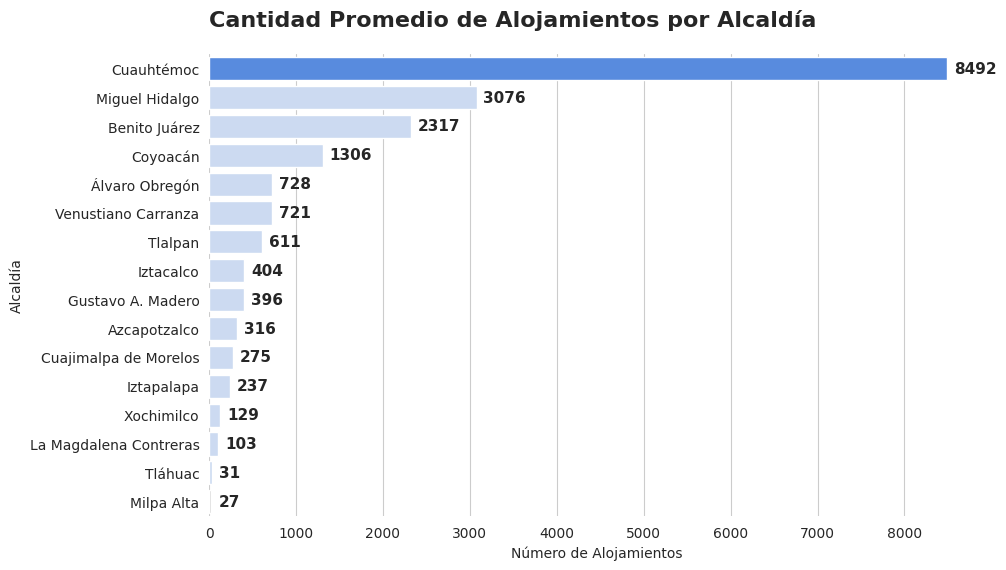

In [176]:
# Realizar gráfico de barras
counts = df_copy['neighbourhood'].value_counts()
order = counts.index
values = counts.values

colors = ['#4285F4' if v == values.max() else '#D3D3D3' if v == values.min() else '#C6D9F7' for v in values]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x=values, y=order, palette=colors, hue=order, legend=False)

for p in ax.patches: # Etiquetas de datos
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=11, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Cantidad Promedio de Alojamientos por Alcaldía', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Número de Alojamientos')
plt.ylabel('Alcaldía')
sns.despine(left=True, bottom=True)
plt.show()

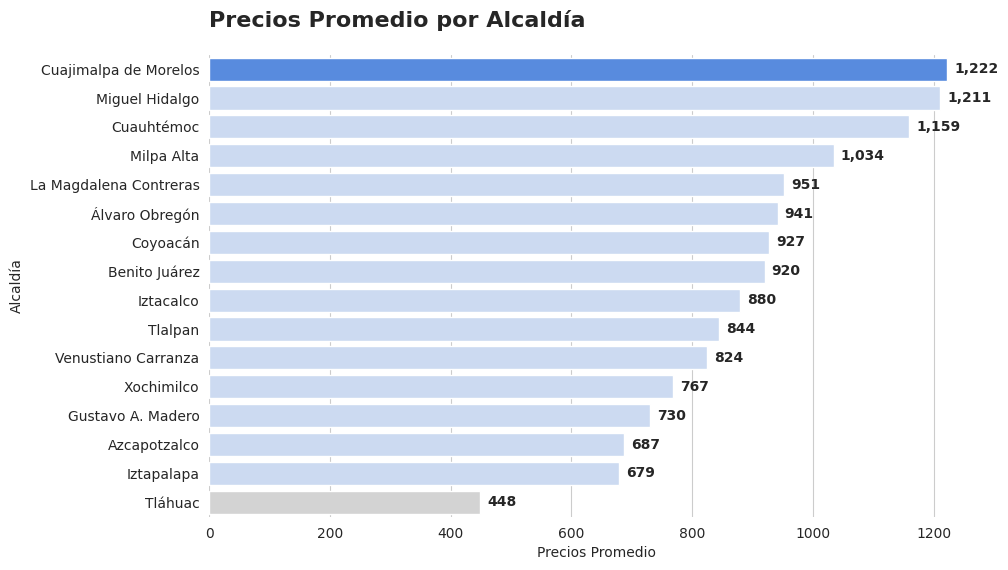

In [177]:
# Realizar gráfico de barras
precios_mean = df_copy.groupby('neighbourhood')['price'].mean().sort_values(ascending=False)
colors_precios = ['#4285F4' if v == precios_mean.max() else '#D3D3D3' if v == precios_mean.min() else '#C6D9F7' for v in precios_mean]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax1 = sns.barplot(x=precios_mean.values, y=precios_mean.index, palette=colors_precios, hue=precios_mean.index, legend=False)

for p in ax1.patches: # Etiquetas y estética
    ax1.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Precios Promedio por Alcaldía', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Precios Promedio')
plt.ylabel('Alcaldía')
sns.despine(left=True, bottom=True)
plt.show()

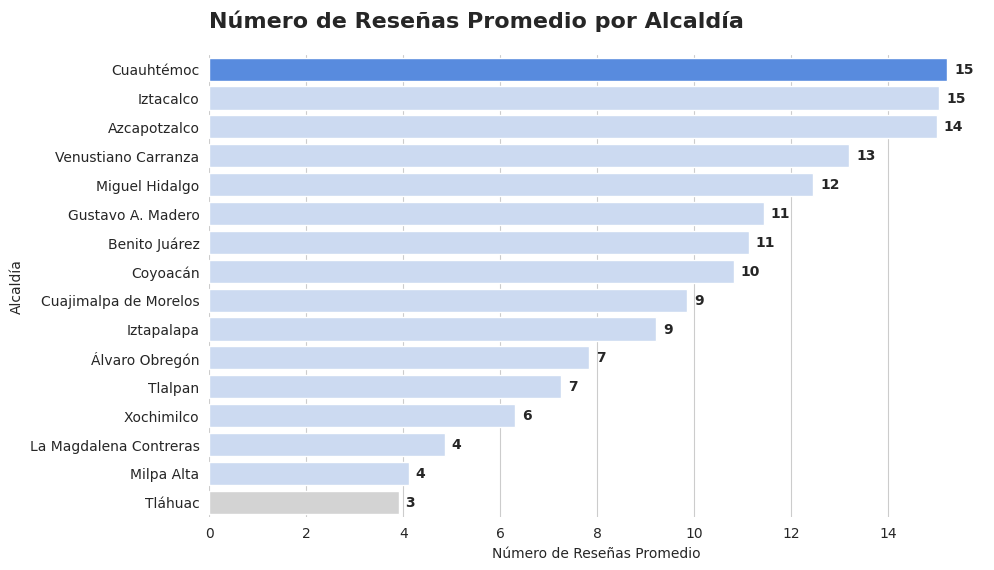

In [178]:
# Realizar gráfico de barras
reviews_mean = df_copy.groupby('neighbourhood')['number_of_reviews_ltm'].mean().sort_values(ascending=False)
colors_reviews = ['#4285F4' if v == reviews_mean.max() else '#D3D3D3' if v == reviews_mean.min() else '#C6D9F7' for v in reviews_mean]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax1 = sns.barplot(x=reviews_mean.values, y=reviews_mean.index, palette=colors_reviews, hue=reviews_mean.index, legend=False)

for p in ax1.patches: # Etiquetas y estética
    ax1.annotate(f'{int(p.get_width()):,}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0), textcoords='offset points')

plt.title('Número de Reseñas Promedio por Alcaldía', loc='left', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Número de Reseñas Promedio')
plt.ylabel('Alcaldía')
sns.despine(left=True, bottom=True)
plt.show()